# Week 06: Business Statistics & Analytics - E-commerce Analysis

## Learning Objectives
By the end of this exercise, you will be able to:
- Calculate key business metrics using pandas
- Create meaningful visualizations for business insights
- Apply statistical concepts to real business scenarios
- Make data-driven recommendations

---

## Business Context

You're working as a Data Analyst for **TechMart**, an e-commerce company. Your manager needs insights from last quarter's sales data to inform strategic decisions for the upcoming quarter.

Your analysis will help answer critical questions about customer behavior, regional performance, and product trends that directly impact business growth.

## Dataset Setup

First, let's generate the synthetic dataset you'll be analyzing:

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
import plotly.express as px
from pandas.api.types import is_datetime64_any_dtype as is_dt

# Set random seed for reproducible results
np.random.seed(42)

# Generate 500 orders from 2023
n_orders = 500

# Create order IDs and customer data
order_id = np.arange(1, n_orders + 1)
customer_id = np.random.randint(1, 101, size=n_orders)
customer_segment = np.random.choice(["Student", "Professional", "Senior"], size=n_orders, p=[0.4, 0.4, 0.2])
region = np.random.choice(["North", "South", "East", "West"], size=n_orders)
order_date = pd.date_range(start="2023-01-01", periods=n_orders, freq="D")
product_category = np.random.choice(["Electronics", "Clothing", "Books", "Home", "Sports"], size=n_orders)
quantity = np.random.randint(1, 5, size=n_orders)
unit_price = np.round(np.random.uniform(10, 200, size=n_orders), 2)
revenue = quantity * unit_price
discount_applied = np.random.choice([0, 5, 10, 15, 20, 25, 30], size=n_orders, p=[0.5,0.1,0.1,0.1,0.05,0.05,0.1])
payment_method = np.random.choice(["Credit Card", "PayPal", "Gift Card", "Debit Card"], size=n_orders)

# Build dataframe
df = pd.DataFrame({
    "order_id": order_id,
    "customer_id": customer_id,
    "customer_segment": customer_segment,
    "region": region,
    "order_date": order_date,
    "product_category": product_category,
    "quantity": quantity,
    "unit_price": unit_price,
    "revenue": revenue,
    "discount_applied": discount_applied,
    "payment_method": payment_method
})

# Save dataset for reference
df.to_csv("ecommerce_data.csv", index=False)
print("✅ Dataset created successfully!")

# Display first few rows
df.head()

✅ Dataset created successfully!


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


## Data Exploration

Let's start by understanding our dataset:

In [ ]:
# Load the data
data = pd.read_csv("ecommerce_data.csv")

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nDataset Shape:", data.shape)
print("\nFirst few rows:")
data.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   customer_segment  500 non-null    object 
 3   region            500 non-null    object 
 4   order_date        500 non-null    object 
 5   product_category  500 non-null    object 
 6   quantity          500 non-null    int64  
 7   unit_price        500 non-null    float64
 8   revenue           500 non-null    float64
 9   discount_applied  500 non-null    int64  
 10  payment_method    500 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB
None

Dataset Shape: (500, 11)

First few rows:


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


Monthly Revenue:
month
2023-01    6626.66
2023-02    6796.03
2023-03    8960.10
2023-04    7713.47
2023-05    7266.80
2023-06    7982.47
2023-07    7981.65
2023-08    6664.64
2023-09    9708.06
2023-10    7287.27
2023-11    8795.85
2023-12    8119.44
2024-01    7268.59
2024-02    8388.91
2024-03    6835.73
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64


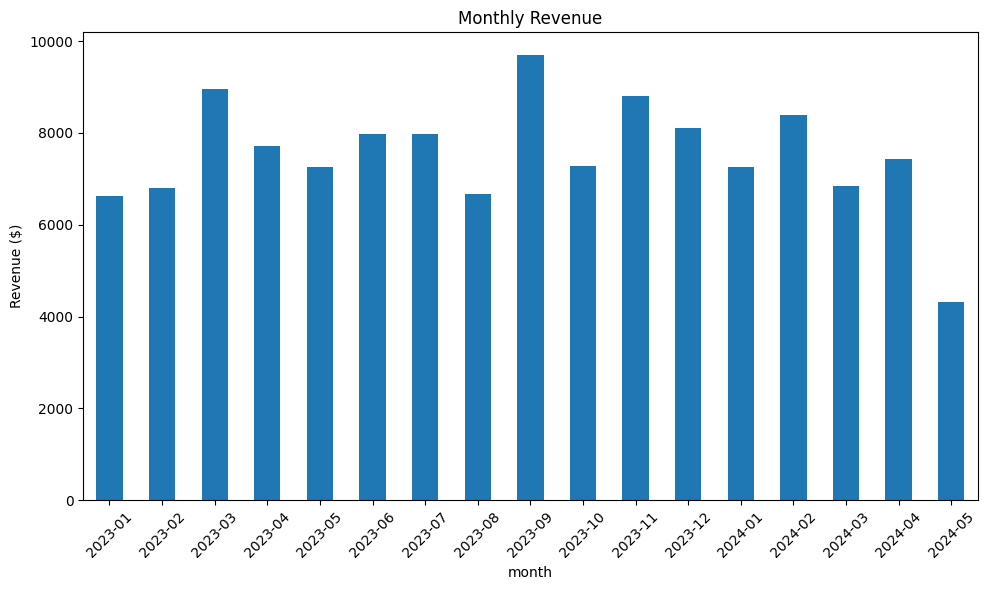

In [ ]:
# Convert order_date to datetime and add helpful columns
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data["day_of_week"] = data["order_date"].dt.day_name()

# Example: Revenue by month
monthly_revenue = data.groupby("month")["revenue"].sum()
print("Monthly Revenue:")
print(monthly_revenue)

# Plot monthly revenue
monthly_revenue.plot(kind="bar", figsize=(10,6), title="Monthly Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Business Questions

Now answer each of the following business questions. Use the starter code above as a reference, and expand your analysis to solve all questions.

In [ ]:
data.head()

,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method,month,day_of_week
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card,2023-01,Sunday
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card,2023-01,Monday
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card,2023-01,Tuesday
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card,2023-01,Wednesday
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card,2023-01,Thursday


### 1. Revenue Overview  
**Question:** What was the company's total revenue last quarter? Break it down by month.  

**Answer:**  
The company's total revenue for the last quarter (**2024 Q2**) was **$11,745.00**.  
- **April 2024:** $7,430.29  
- **May 2024:** $4,314.71  

Revenue was higher in April compared to May. 



In [ ]:
# Q1: Revenue Overview — last quarter + monthly breakdown

# make sure dates are datetime
if not is_dt(data["order_date"]):
    data["order_date"] = pd.to_datetime(data["order_date"], errors="coerce")

# find the last quarter in the data (year + quarter)
last_q = data["order_date"].dt.to_period("Q").max()

# filter rows from that quarter
dq = data[data["order_date"].dt.to_period("Q") == last_q].copy()

# sum revenue by month in that quarter (keep calendar order)
monthly_rev = (
    dq.assign(
        month_num=dq["order_date"].dt.month,
        month=dq["order_date"].dt.strftime("%B %Y")
    )
    .groupby(["month_num", "month"], as_index=False)["revenue"]
    .sum()
    .sort_values("month_num")
    .drop(columns="month_num")
)

# total revenue in the quarter
total_rev = monthly_rev["revenue"].sum()
display(Markdown(f"**Last Quarter:** `{last_q}`  **Total Revenue:** `${total_rev:,.2f}`"))

# bar chart
fig = px.bar(
    monthly_rev, x="month", y="revenue",
    template="plotly_dark",
    color_discrete_sequence=["#00CC96"],
    title=f"Monthly Revenue — {last_q}"
)
fig.update_layout(xaxis_title="Month", yaxis_title="Revenue ($)")
fig.show()

# show the table
monthly_rev


**Last Quarter:** `2024Q2`  **Total Revenue:** `$11,745.00`

,month,revenue
0,April 2024,7430.29
1,May 2024,4314.71


### 2. Top Customers
Who are the top 5 customers by total revenue contribution?

In [ ]:
# Q2: Top 5 Customers by Total Revenue

# group by customer and sum total revenue
top_customers = (
    data.groupby("customer_id", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
    .head(5)
)

# show title and total list
display(Markdown("**Top 5 Customers by Total Revenue**"))

# bar chart
fig = px.bar(
    top_customers.astype({"customer_id": "string"}),
    x="customer_id", y="revenue",
    template="plotly_dark",
    color_discrete_sequence=["#7AA6C2"],
    title="Top 5 Customers"
)
fig.update_layout(xaxis_title="Customer ID", yaxis_title="Revenue ($)")
fig.show()

# table
top_customers


**Top 5 Customers by Total Revenue**

,customer_id,revenue
60,62,4448.39
22,24,3369.44
88,90,2976.78
90,92,2838.74
95,97,2835.62


### 3. Segment Analysis  
**Question:** Which customer segment (Student, Professional, Senior) spends the most on average per order?  

**Answer:**  
The **Senior** segment has the highest average spending per order at **$262.13**, followed by **Professionals ($255.65)** and **Students ($253.81)**.  
This shows that seniors tend to spend slightly more per order compared to other segments.


In [ ]:
# Q3: Segment Analysis — average spending per order

# find average revenue per order for each segment
segment_avg = (
    data.groupby("customer_segment", as_index=False)["revenue"]
    .mean()
    .sort_values("revenue", ascending=False)
    .rename(columns={"revenue": "avg_order_value"})
)

# keep the bar order same as the sorted table
segment_avg["customer_segment"] = pd.Categorical(
    segment_avg["customer_segment"], 
    categories=segment_avg["customer_segment"].tolist(),
    ordered=True
)

# bar chart 
fig = px.bar(
    segment_avg,
    x="customer_segment", y="avg_order_value",
    color="customer_segment",
    template="plotly_dark",
    color_discrete_sequence=["#007ACC", "#00B050", "#6A5ACD"],  # blue, green, purple
    title="Average Spending per Order by Segment"
)
fig.update_layout(xaxis_title="Customer Segment", yaxis_title="Average Revenue ($)", showlegend=False)
fig.show()

# show the table
segment_avg


,customer_segment,avg_order_value
1,Senior,262.133925
0,Professional,255.652674
2,Student,253.812087


### 4. Regional Trends  
**Question:** Which region generated the highest revenue? Which region had the highest average order size?  

**Answer:**  
The **South** region generated the highest total revenue at **$34,839.45**, followed closely by the **North** region with **$34,351.69**.  
The **South** region also had the highest average order size of **$274.33**, indicating both strong sales volume and higher spending per order in that region.


In [ ]:
# Q4: Regional Trends — total revenue and average order size

# total revenue by region 
region_total = (
    data.groupby("region", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
    .rename(columns={"revenue": "total_revenue"})
)

# average order size by region 
region_avg = (
    data.groupby("region", as_index=False)["revenue"]
    .mean()
    .sort_values("revenue", ascending=False)
    .rename(columns={"revenue": "avg_order_value"})
)

# fixed colors per region 
region_colors = {
    "North": "#800080",  # purple
    "South": "#00B050",  # green
    "East":  "#007ACC",  # blue
    "West":  "#C44E52"   # red
}

# bar chart — total revenue
fig1 = px.bar(
    region_total, x="region", y="total_revenue",
    color="region",
    template="plotly_dark",
    color_discrete_map=region_colors,
    title="Total Revenue by Region"
)
fig1.update_layout(xaxis_title="Region", yaxis_title="Total Revenue ($)", showlegend=False)
fig1.show()

# bar chart — average order size 
fig2 = px.bar(
    region_avg, x="region", y="avg_order_value",
    color="region",
    template="plotly_dark",
    color_discrete_map=region_colors,
    title="Average Order Size by Region"
)
fig2.update_layout(xaxis_title="Region", yaxis_title="Average Revenue per Order ($)", showlegend=False)
fig2.show()

# tables
region_total, region_avg


(  region  total_revenue
 2  South       34839.45
 1  North       34351.69
 0   East       31221.80
 3   West       27727.73,
   region  avg_order_value
 2  South       274.326378
 1  North       258.283383
 3   West       252.070273
 0   East       240.167692)

### 5. Product Category Performance  
**Question:** Which product category is most popular by quantity vs. by revenue?  

**Answer:**  
The **Home** category is the most popular by quantity sold (**269 units**) and also generates the highest total revenue (**$29,871.47**).  
This shows that Home products are both in high demand and contribute the most to overall sales, followed by **Electronics ($25,498.31)** and **Clothing ($24,804.57)**.


In [ ]:
# Q5: Product Category Performance — most popular by quantity vs. by revenue

# total quantity sold by category
category_qty = (
    data.groupby("product_category", as_index=False)["quantity"]
    .sum()
    .sort_values("quantity", ascending=False)
)

# total revenue by category
category_rev = (
    data.groupby("product_category", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

# consistent colors for both charts
category_colors = {
    "Electronics": "#007ACC",  # blue
    "Clothing": "#00B050",     # green
    "Books": "#800080",        # purple
    "Home": "#C44E52",         # red
    "Sports": "#FF9900"        # orange
}

# bar chart — quantity sold
fig1 = px.bar(
    category_qty,
    x="product_category", y="quantity",
    color="product_category",
    template="plotly_dark",
    color_discrete_map=category_colors,
    title="Total Quantity Sold by Product Category"
)
fig1.update_layout(xaxis_title="Product Category", yaxis_title="Total Quantity", showlegend=False)
fig1.show()

# bar chart — total revenue
fig2 = px.bar(
    category_rev,
    x="product_category", y="revenue",
    color="product_category",
    template="plotly_dark",
    color_discrete_map=category_colors,
    title="Total Revenue by Product Category"
)
fig2.update_layout(xaxis_title="Product Category", yaxis_title="Total Revenue ($)", showlegend=False)
fig2.show()

# tables
category_qty, category_rev


(  product_category  quantity
 3             Home       269
 1         Clothing       253
 4           Sports       246
 2      Electronics       239
 0            Books       227,
   product_category   revenue
 3             Home  29871.47
 2      Electronics  25498.31
 1         Clothing  24804.57
 0            Books  24046.06
 4           Sports  23920.26)

### 6. Discount Effectiveness  
**Question:** Do discounted orders generate higher or lower revenue per order compared to non-discounted orders?  

**Answer:**  
**Discounted orders** have a higher average revenue per order (**$263.83**) compared to **non-discounted orders ($248.30)**, a difference of about **$15.53**.  
This suggests that discounts encourage customers to spend slightly more overall.


In [ ]:
# Q6: Discount Effectiveness — compare discounted vs. non-discounted orders

# create a flag for discounted vs non-discounted
data["is_discounted"] = np.where(data["discount_applied"] > 0, "Discounted", "Non-Discounted")

# calculate average revenue per order for each group
discount_compare = (
    data.groupby("is_discounted", as_index=False)["revenue"]
    .mean()
    .rename(columns={"revenue": "avg_revenue_per_order"})
    .sort_values("avg_revenue_per_order", ascending=False)
)

# color mapping for both groups
discount_colors = {
    "Discounted": "#00B050",       # green
    "Non-Discounted": "#800080"    # purple
}

# bar chart
fig = px.bar(
    discount_compare,
    x="is_discounted", y="avg_revenue_per_order",
    color="is_discounted",
    template="plotly_dark",
    color_discrete_map=discount_colors,
    title="Average Revenue per Order — Discounted vs Non-Discounted"
)
fig.update_layout(xaxis_title="Order Type", yaxis_title="Average Revenue ($)", showlegend=False)
fig.show()

# table
discount_compare

,is_discounted,avg_revenue_per_order
0,Discounted,263.831362
1,Non-Discounted,248.296337


### 7. Payment Method Usage  
**Question:** What percentage of orders use each payment method? Does any payment method correlate with higher spending?  

**Answer:**  
**Credit Card** is the most used payment method (**27.4%** of orders), followed by **Gift Card (24.8%)** and **Debit Card (24.6%)**.  
In terms of spending, **Debit Card** users have the highest average revenue per order (**$275.98**), indicating that customers paying with Debit Cards tend to spend more per purchase.


In [ ]:
# Q7: Payment Method Usage — percentage of orders and average spending

# percentage of orders per payment method
payment_counts = (
    data["payment_method"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
payment_counts.columns = ["payment_method", "percentage"]  

# average revenue per order for each payment method
payment_avg = (
    data.groupby("payment_method", as_index=False)["revenue"]
    .mean()
    .rename(columns={"revenue": "avg_revenue"})
)

# merge both for comparison
payment_summary = (
    pd.merge(payment_counts, payment_avg, on="payment_method")
    .sort_values("percentage", ascending=False)
)

# color mapping
payment_colors = {
    "Credit Card": "#007ACC",
    "PayPal": "#00B050",
    "Gift Card": "#800080",
    "Debit Card": "#C44E52"
}

# bar chart — percentage of orders
fig1 = px.bar(
    payment_summary,
    x="payment_method", y="percentage",
    color="payment_method",
    template="plotly_dark",
    color_discrete_map=payment_colors,
    title="Percentage of Orders by Payment Method"
)
fig1.update_layout(xaxis_title="Payment Method", yaxis_title="Percentage of Orders (%)", showlegend=False)
fig1.show()

# bar chart — average revenue per order
fig2 = px.bar(
    payment_summary,
    x="payment_method", y="avg_revenue",
    color="payment_method",
    template="plotly_dark",
    color_discrete_map=payment_colors,
    title="Average Revenue per Order by Payment Method"
)
fig2.update_layout(xaxis_title="Payment Method", yaxis_title="Average Revenue ($)", showlegend=False)
fig2.show()

# table
payment_summary


,payment_method,percentage,avg_revenue
0,Credit Card,27.4,257.444234
1,Gift Card,24.8,254.362500
2,Debit Card,24.6,275.980650
3,PayPal,23.2,236.071034


### 8. Seasonality Check  
**Question:** Plot revenue by day of week — are weekends busier than weekdays?  

**Answer:**  
Weekdays show slightly higher total revenue overall, with **Tuesday ($18,968.41)** and **Wednesday ($18,908.21)** leading.  
**Saturday ($18,660.35)** and **Friday ($18,522.40)** also perform well, but weekends are not significantly busier than weekdays.  
Overall, customer activity remains fairly consistent throughout the week, with a small midweek peak.


In [ ]:
# Q8: Seasonality Check — revenue by day of week

# total revenue by day of week
dow_revenue = (
    data.groupby("day_of_week", as_index=False)["revenue"]
    .sum()
)

# set correct weekday order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_revenue["day_of_week"] = pd.Categorical(dow_revenue["day_of_week"], categories=day_order, ordered=True)
dow_revenue = dow_revenue.sort_values("day_of_week")

# bar chart
fig = px.bar(
    dow_revenue,
    x="day_of_week", y="revenue",
    template="plotly_dark",
    color="day_of_week",
    color_discrete_sequence=px.colors.qualitative.Vivid,
    title="Total Revenue by Day of Week"
)
fig.update_layout(xaxis_title="Day of Week", yaxis_title="Total Revenue ($)", showlegend=False)
fig.show()

# table
dow_revenue


,day_of_week,revenue
1,Monday,17704.70
5,Tuesday,18968.41
6,Wednesday,18908.21
4,Thursday,17846.36
0,Friday,18522.40
2,Saturday,18660.35
3,Sunday,17530.24


### 9. Profitability (Stretch)  
**Question:** Assume profit margin = 20% of revenue. Estimate total profit and identify the most profitable region.  

**Answer:**  
The company’s **total profit** is estimated at **$25,628.13** based on a 20% profit margin.  
The **South** region is the most profitable with **$6,967.89**, followed by the **North ($6,870.34)** and **East ($6,244.36)** regions.  
This indicates that the South region not only generates the highest revenue but also contributes the most to overall profit.


In [ ]:
# Q9: Profitability — total profit and most profitable region

# assume profit margin = 20% of revenue
data["profit"] = data["revenue"] * 0.20

# total profit
total_profit = data["profit"].sum()

# profit by region
region_profit = (
    data.groupby("region", as_index=False)["profit"]
    .sum()
    .sort_values("profit", ascending=False)
)

# bar chart — profit by region
fig = px.bar(
    region_profit,
    x="region", y="profit",
    color="region",
    template="plotly_dark",
    color_discrete_sequence=px.colors.qualitative.Vivid,
    title="Total Profit by Region"
)
fig.update_layout(xaxis_title="Region", yaxis_title="Total Profit ($)", showlegend=False)
fig.show()

# show the tables
total_profit, region_profit


(np.float64(25628.134),
   region    profit
 2  South  6967.890
 1  North  6870.338
 0   East  6244.360
 3   West  5545.546)

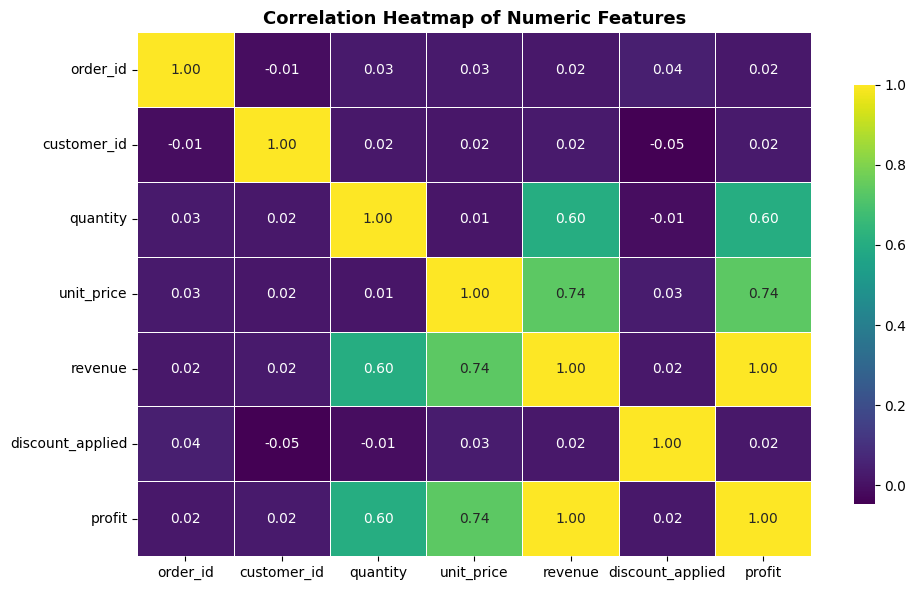

In [ ]:
# Correlation Heatmap — numeric relationships

# select only numeric columns
numeric_cols = data.select_dtypes(include=np.number)

# correlation matrix
corr = numeric_cols.corr()

# plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="viridis",       # dark-professional palette
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


### 10. Business Recommendation  
**Question:** Based on your findings, recommend one strategy (e.g., focus on certain customer segments, increase discounts, promote specific regions/products).  

**Answer:**  
The company should prioritize promoting **Home products**, as they generated the highest sales volume and revenue by a clear margin.  
Marketing efforts could focus on increasing visibility and inventory for Home products, especially in the **South region**, which is already the most profitable market.  
Since **Seniors** spend the most per order and **discounted orders** lead to slightly higher revenue, offering limited-time discounts on Home products for this segment could drive even greater sales and profitability.  

*Note:* Since this dataset was randomly generated, the patterns and relationships are limited.  
With real store data, stronger and more meaningful trends could be identified to guide business strategy more accurately.


---

## Submission Requirements

1. **Complete code** for all 10 questions
2. **Clear visualizations** where appropriate  
3. **Brief interpretation** of each result
4. **Final business recommendation** with supporting data

Remember: Focus on what the numbers tell us about the business, not just the calculations themselves.